# Determine the latent space overlap for goodness of fit
----

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from get_model_probabilities import *
from projection_overlap import *
import scienceplots
plt.style.use(["science","grid"])

In [9]:
ifilter='concat'
all_models = glob(f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth")

In [4]:
latent = get_latent_space(all_models)

30it [00:00, 259.00it/s]
30it [20:09, 40.31s/it]


# Latent space distances 

In [5]:
latent_distances = []
latent_quantiles = []
for imodel in range(len(latent['all_cross_sections'])-1):

    
    origin = latent['latent_space'][0][imodel].detach().numpy()
    
    cross_sections = latent['all_cross_sections'][imodel+1]
    latent_spaces = latent['latent_space'][imodel+1]

    unique_cross = np.unique(cross_sections)
    this_latent_distances = []
    this_latent_quantile = []
    for icross in unique_cross:
        if icross == -1:
            raise

        sim_origin = torch.mean(latent_spaces,axis=0).detach().numpy()
            
        obs_distance = np.sqrt(np.sum((origin-sim_origin)**2))
        sim_distance = np.array([ np.sqrt(np.sum( (i.detach().numpy() - sim_origin)**2)) for i in latent_spaces[icross == cross_sections]])
        
        distance = obs_distance / sim_distance
        this_latent_distances.append(distance)
        this_latent_quantile.append(np.quantile( distance, [0.16,0.84]))

    latent_distances.append(  this_latent_distances)
    latent_quantiles.append(this_latent_quantile)
    
pkl.dump([unique_cross, latent_distances, latent_quantiles], open("pickles/latent_zs_space.pkl","wb"))

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `/Users/davidharvey/Desktop/goodness_of_fit.pdf'.


0

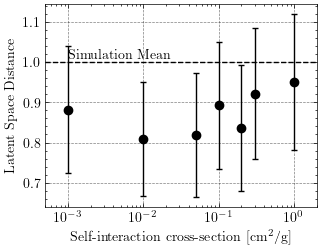

In [6]:
nmodels=30

av_distances = [ np.mean([ np.mean(latent_distances[i][j]) for i in range(nmodels)]) for j in range(len(unique_cross))]
err = [ np.std([ np.mean(latent_distances[i][j]) for i in range(nmodels)]) for j in range(len(unique_cross))]
ax = plt.gca()
unique_cross[0] = 1e-3
ax.errorbar( unique_cross, av_distances, err, color='k', fmt='o', capsize=2)
ax.plot([5e-4,2],[1,1],'k--')
ax.text(0.001,1.0, 'Simulation Mean', ha='left', va='bottom')
ax.set_xlim(5e-4,2)
ax.set_xscale('log')
ax.set_ylabel("Latent Space Distance")
ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
fname="/Users/davidharvey/Desktop/goodness_of_fit.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")